<a href="https://colab.research.google.com/github/vg137/ibd-causal-multiomics/blob/main/01_gwas_to_genes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# For accessing the dataset
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Mounted at /content/drive


In [2]:
# file locations and names
data_dir = "/content/drive/MyDrive/ibd_data"
gwas_data_subdir = "gwas/raw"
gwas_name = "GCST90473841"
gwas_file_path = f"{data_dir}/{gwas_data_subdir}/{gwas_name}.h.tsv.gz"

The metadata about this GWAS study can be found in the `yaml` file that comes with the compressed GWAS data file

In [3]:
gwas_metadata_filepath = f"{data_dir}/{gwas_data_subdir}/{gwas_name}.h.tsv.gz-meta.yaml"
with open(gwas_metadata_filepath, "r") as f:
    print(f.read())

adjusted_covariates:
- 'genetic PCs {1-20} '
- ' sex '
- ' age at baseline '
- ' sex:age '
- ' age2 '
- ' sequencing protocol'
analysis_software: regenie_v3.2.5
author_notes: 'pre-print describing the study here: https://www.medrxiv.org/content/10.1101/2023.12.06.23299426v1'
coordinate_system: 1-based
data_file_md5sum: c2962caddcbc75157fbaf654fa10a0a5
data_file_name: GCST90473841.h.tsv.gz
date_metadata_last_modified: 2025-07-30
file_type: GWAS-SSF v1.0
genome_assembly: GRCh38
genotyping_technology:
- Whole genome sequencing
gwas_catalog_api: https://www.ebi.ac.uk/gwas/rest/api/studies/GCST90473841
gwas_id: GCST90473841
harmonisation_reference: ftp://ftp.ensembl.org/pub/release-95/fasta/homo_sapiens/dna/
is_harmonised: true
is_sorted: true
ontology_mapping:
- ''
samples:
- ancestry_method:
  - gnomAD v3.1
  case_control_study: true
  sample_ancestry:
  - Non-Finish European
  sample_ancestry_category:
  - European
  sample_size: 458440
sex: combined
trait_description:
- 'ICD10 K58: Irri

Since we will be streaming data from the compressed GWAS file frequently, we define a simple function to construct an iterator over the chunks of the file.

In [4]:
def get_gwas_iterator(chunksize=10**6, columns=None):
    """Returns a new iterator for the compressed GWAS file"""

    gwas_chunk_iterator = pd.read_csv(gwas_file_path,
                                        sep="\t", # standard GWAS files use TAB separated values
                                        compression="gzip", # standard GWAS files use gzip compression
                                        chunksize=chunksize,
                                        usecols=columns
                                      )

    return gwas_chunk_iterator

### Generating a Parquet file

For faster manipulation of the GWAS data, we will convert it to a better suited format called [parquet](https://en.wikipedia.org/wiki/Apache_Parquet)

In [5]:
import pyarrow as pa
import pyarrow.parquet as pq

parquet_data_subdir = "gwas/parquet"
parquet_file_path = f"{data_dir}/{parquet_data_subdir}/{gwas_name}.parquet"

Uncomment the following block, if the parquet file has not been generated yet or is not available

In [6]:
# writer = None

# for chunk in get_gwas_iterator():
#     table = pa.Table.from_pandas(chunk, preserve_index=False)

#     if writer is None:
#         writer = pq.ParquetWriter(parquet_file_path,
#                                     table.schema,
#                                     compression="zstd",
#                                  )

#     writer.write_table(table)

# if writer is not None:
#     writer.close()

In [7]:
def get_parquet_iterator(batch_size=10**6, columns=None):
    """Returns a new iterator for the parquet file"""

    pf = pq.ParquetFile(parquet_file_path)

    return pf.iter_batches(batch_size=batch_size, columns=columns)

### Quality control

#### Basic info and sanity checks

In [8]:
pq.read_metadata(parquet_file_path) # metadata like number of rows and columns

  created_by: parquet-cpp-arrow version 18.1.0
  num_columns: 18
  num_rows: 84399074
  num_row_groups: 85
  format_version: 2.6
  serialized_size: 172025

Total rows = 84,399,074 $\implies$ These many different SNPs were studied

In [9]:
pq.read_schema(parquet_file_path).names # all the columns in the gwas summary statistics

['chromosome',
 'base_pair_location',
 'effect_allele',
 'other_allele',
 'beta',
 'standard_error',
 'effect_allele_frequency',
 'p_value',
 'rsid',
 'ID',
 'INFO',
 'n',
 'TEST',
 'CHISQ',
 'EXTRA',
 'hm_coordinate_conversion',
 'hm_code',
 'variant_id']

In [10]:
pq.read_table(parquet_file_path, columns=["chromosome"]).to_pandas()["chromosome"].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22])

From the above output, we learn that all 22 pairs of autosomal chromosomes are studied but not the X/Y chromosomes

#### Missing values

In [11]:
important_columns = ["chromosome", "base_pair_location", "p_value"]

for col in important_columns:
    print(col, pd.read_parquet(parquet_file_path, columns=[col])[col].isna().sum())

chromosome 0
base_pair_location 0
p_value 0


Above output shows that none of the important parameters are missing

#### p-value histogram

Text(0.5, 0.98, 'Histogram of p-values')

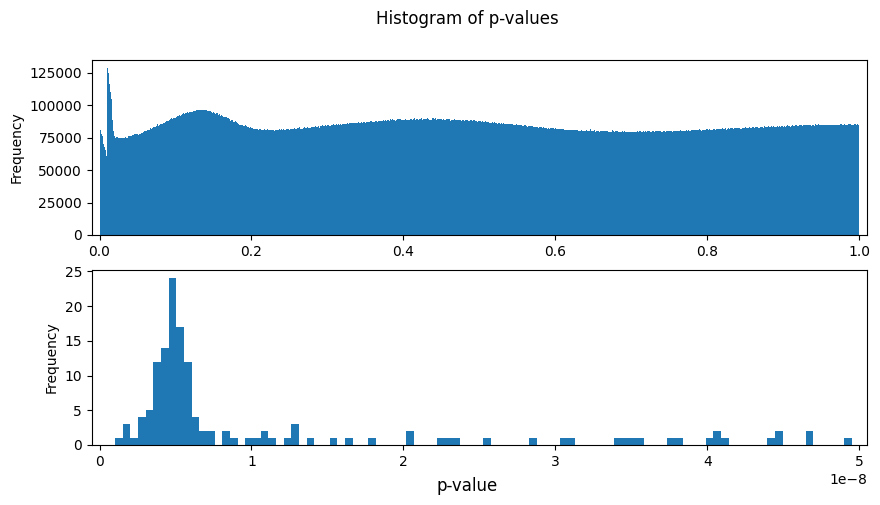

In [43]:
fig, axs = plt.subplots(2, figsize=(10, 5));

gwst = 5 * 10**-8 # Genome-wide significance threshold

# histogram of all p-values
num_bins_1 = 1000
bins_1 = np.linspace(0, 1, num_bins_1)
counts_1 = np.zeros(num_bins_1 - 1)

# histogram of p-values below gwst
num_bins_2 = 100
bins_2 = np.linspace(0, gwst, num_bins_2)
counts_2 = np.zeros(num_bins_2 - 1)

for batch in get_parquet_iterator(columns=["p_value"]):
    counts_1 += np.histogram(batch["p_value"], bins=bins_1)[0]
    counts_2 += np.histogram(batch["p_value"], bins=bins_2)[0]

axs[0].hist(bins_1[:-1], bins_1, weights=counts_1)
axs[0].set_ylabel("Frequency")
axs[0].margins(x=0.01)

axs[1].hist(bins_2[:-1], bins_2, weights=counts_2)
axs[1].set_ylabel("Frequency")
axs[1].margins(x=0.01)

fig.supxlabel("p-value")
fig.suptitle("Histogram of p-values")

The p-values are distributed almost uniformly apart from spikes near 0. This means that few of the SNPs have very low p-values indicating that some of the SNPs may be strong causal candidates. The second histogram shows this more clearly because only the p-values below the genome-wide significance threshold are counted

#### Manhattan plot

In [25]:
manhattan_columns = ["chromosome", "base_pair_location", "p_value"]

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

for batch in get_parquet_iterator(columns=manhattan_columns):
    transformed_p_values = -np.log10(batch["p_value"])
    ax.plot(batch["base_pair_location"], transformed_p_values, ".", markersize=1)